<a href="https://colab.research.google.com/github/fadhilra101/vertical-transition-velocity/blob/main/VerticalTransitionVelocity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install library resmi dari StatsBomb
!pip install statsbombpy

# Import library untuk manipulasi data
import pandas as pd
import numpy as np

# Import modul sb untuk menarik data dari StatsBomb
from statsbombpy import sb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.8/63.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.0 MB/s eta 0:00:00


In [2]:
# Menarik daftar pertandingan Premier League 2015/2016 (competition_id = 2)
matches = sb.matches(competition_id=2, season_id=27)

# Tampilkan list tim untuk memastikan Leicester ada
print(matches['home_team'].unique())

/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


['Chelsea' 'Aston Villa' 'Arsenal' 'Swansea City' 'Southampton'
 'Liverpool' 'Leicester City' 'West Bromwich Albion' 'Newcastle United'
 'Everton' 'Crystal Palace' 'Tottenham Hotspur' 'Sunderland' 'Stoke City'
 'Manchester United' 'AFC Bournemouth' 'Norwich City' 'Watford'
 'Manchester City' 'West Ham United']


In [3]:
# Filter pertandingan Leicester City
leicester_matches = matches[(matches['home_team'] == 'Leicester City') | (matches['away_team'] == 'Leicester City')]

# Ambil ID match pertama dan tarik event-nya
sample_match_id = leicester_matches.iloc[0]['match_id']
events = sb.events(match_id=sample_match_id)

print(f"Data Match ID {sample_match_id} berhasil ditarik. Total event: {events.shape[0]}")
events[['timestamp', 'team', 'type', 'possession', 'possession_team', 'location']].head()

/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(


Data Match ID 3754058 berhasil ditarik. Total event: 3576


,timestamp,team,type,possession,possession_team,location
0,00:00:00.000,Leicester City,Starting XI,1,Leicester City,NaN
1,00:00:00.000,AFC Bournemouth,Starting XI,1,Leicester City,NaN
2,00:00:00.000,AFC Bournemouth,Half Start,1,Leicester City,NaN
3,00:00:00.000,Leicester City,Half Start,1,Leicester City,NaN
4,00:00:00.000,AFC Bournemouth,Half Start,82,AFC Bournemouth,NaN


In [4]:
# 1. Extract X and Y coordinates from the location column
events['x'] = events['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else np.nan)
events['y'] = events['location'].apply(lambda loc: loc[1] if isinstance(loc, list) else np.nan)

# 2. Convert timestamp to total seconds
events['time_seconds'] = pd.to_timedelta(events['timestamp']).dt.total_seconds()

# Check the result
events[['timestamp', 'time_seconds', 'location', 'x', 'y']].head()

,timestamp,time_seconds,location,x,y
0,00:00:00.000,0.0,NaN,NaN,NaN
1,00:00:00.000,0.0,NaN,NaN,NaN
2,00:00:00.000,0.0,NaN,NaN,NaN
3,00:00:00.000,0.0,NaN,NaN,NaN
4,00:00:00.000,0.0,NaN,NaN,NaN


In [5]:
# 1. Drop events without coordinates
valid_events = events.dropna(subset=['x']).copy()

# 2. Keep only events by the team owning the possession
valid_events = valid_events[valid_events['team'] == valid_events['possession_team']]

# 3. Exclude 'Clearance' events to avoid skewed distances from panic kicks
valid_events = valid_events[valid_events['type'] != 'Clearance']

# 4. Sort chronologically
valid_events = valid_events.sort_values(by=['possession', 'time_seconds'])

# 5. Group by possession and team
possession_metrics = valid_events.groupby(['possession', 'possession_team']).agg(
    start_x=('x', 'first'),
    end_x=('x', 'last'),
    start_time=('time_seconds', 'first'),
    end_time=('time_seconds', 'last')
).reset_index()

# 6. Calculate Distance and Duration
possession_metrics['progression_distance'] = possession_metrics['end_x'] - possession_metrics['start_x']
possession_metrics['duration_seconds'] = possession_metrics['end_time'] - possession_metrics['start_time']

# 7. Calculate Velocity ONLY for established possessions (duration > 4 seconds)
possession_metrics['vertical_transition_velocity'] = np.where(
    possession_metrics['duration_seconds'] > 4,
    possession_metrics['progression_distance'] / possession_metrics['duration_seconds'],
    0
)

# Sort by highest velocity to verify the clean data
possession_metrics.sort_values(by='vertical_transition_velocity', ascending=False).head()

,possession,possession_team,start_x,end_x,start_time,end_time,progression_distance,duration_seconds,vertical_transition_velocity
57,59,Leicester City,6.0,88.4,1969.328,1973.510,82.4,4.182,19.703491
168,170,AFC Bournemouth,6.0,80.0,2354.421,2360.359,74.0,5.938,12.462108
134,136,Leicester City,7.0,85.9,1498.425,1505.424,78.9,6.999,11.273039
60,62,Leicester City,68.3,112.1,2027.713,2032.207,43.8,4.494,9.746328
45,47,Leicester City,33.0,111.3,1540.350,1549.025,78.3,8.675,9.025937


In [6]:
# Define conditions based on our logic
conditions = [
    # Counter-Attack: Start in own third (x <= 40), end deep in opponent half (x >= 100), duration <= 15s
    (possession_metrics['start_x'] <= 40) & (possession_metrics['end_x'] >= 100) & (possession_metrics['duration_seconds'] <= 15),

    # High Turnover: Win ball high up the pitch (x >= 80) and end deep
    (possession_metrics['start_x'] >= 80) & (possession_metrics['end_x'] >= 100),

    # Slow Build-up: Attack takes longer than 15 seconds
    (possession_metrics['duration_seconds'] > 15)
]

# Define the category names matching the conditions
choices = ['Counter-Attack', 'High Turnover', 'Slow Build-up']

# Apply logic to a new column, everything else goes to 'Other'
possession_metrics['attack_category'] = np.select(conditions, choices, default='Other')

# Check how many possessions fall into each category for both teams
possession_metrics.groupby(['possession_team', 'attack_category']).size().unstack(fill_value=0)

attack_category,Counter-Attack,High Turnover,Other,Slow Build-up
possession_team,,,,
AFC Bournemouth,2,6,54,34
Leicester City,3,12,41,39


In [7]:
# 1. Mari kita intip detail serangan yang dikategorikan sebagai 'Counter-Attack'
print("Detail Counter-Attacks:")
display(possession_metrics[possession_metrics['attack_category'] == 'Counter-Attack'])

# 2. Mari kita cek 5 serangan dengan Vertical Transition Velocity (VTV) paling tinggi
# Kita filter durasi > 2 detik untuk menghindari anomali data (misal: 1 operan langsung hilang)
top_velocity = possession_metrics[possession_metrics['duration_seconds'] > 2].sort_values(
    by='vertical_transition_velocity', ascending=False
).head(5)

print("\nTop 5 Serangan Tercepat (Berdasarkan VTV):")
display(top_velocity[['possession_team', 'start_x', 'end_x', 'duration_seconds', 'progression_distance', 'vertical_transition_velocity', 'attack_category']])

Detail Counter-Attacks:


,possession,possession_team,start_x,end_x,start_time,end_time,progression_distance,duration_seconds,vertical_transition_velocity,attack_category
30,32,Leicester City,28.9,114.7,1069.439,1082.474,85.8,13.035,6.582278,Counter-Attack
45,47,Leicester City,33.0,111.3,1540.350,1549.025,78.3,8.675,9.025937,Counter-Attack
56,58,AFC Bournemouth,29.1,112.6,1920.209,1934.772,83.5,14.563,5.733709,Counter-Attack
115,117,AFC Bournemouth,30.5,109.2,1033.098,1042.349,78.7,9.251,8.507188,Counter-Attack
159,161,Leicester City,36.7,118.1,2095.186,2106.540,81.4,11.354,7.169280,Counter-Attack



Top 5 Serangan Tercepat (Berdasarkan VTV):


,possession_team,start_x,end_x,duration_seconds,progression_distance,vertical_transition_velocity,attack_category
57,Leicester City,6.0,88.4,4.182,82.4,19.703491,Other
168,AFC Bournemouth,6.0,80.0,5.938,74.0,12.462108,Other
134,Leicester City,7.0,85.9,6.999,78.9,11.273039,Other
60,Leicester City,68.3,112.1,4.494,43.8,9.746328,Other
45,Leicester City,33.0,111.3,8.675,78.3,9.025937,Counter-Attack


In [8]:
# Inspect the details of the events inside the anomalous possession
anomaly_154 = events[events['possession'] == 154]

# Display the event type and coordinates
anomaly_154[['time_seconds', 'team', 'type', 'x', 'y']]

,time_seconds,team,type,x,y
858,1952.279,AFC Bournemouth,Pass,6.0,36.0
859,1959.160,Leicester City,Pass,37.7,30.0
860,1969.898,AFC Bournemouth,Pass,31.0,77.2
1797,1959.160,AFC Bournemouth,Ball Receipt*,61.4,42.2
1798,1961.517,Leicester City,Ball Receipt*,57.0,7.8
2573,1961.517,Leicester City,Carry,57.0,7.8
2574,1967.636,AFC Bournemouth,Carry,31.5,73.3
2990,1964.913,AFC Bournemouth,Pressure,34.2,69.2
2991,1969.353,Leicester City,Pressure,86.2,4.1
3062,1967.636,Leicester City,Dispossessed,88.6,6.8


In [14]:
# Create empty list to store metrics for all matches
all_match_ids = matches['match_id'].tolist()
all_possession_metrics = []
failed_matches = []

print(f"Extracting data from {len(all_match_ids)} matches. This will take a while...\n")

for match_id in all_match_ids:
    try:
        # 1. Pull events
        match_events = sb.events(match_id=match_id)

        # 2. Extract 'x' coordinate
        valid_events = match_events.dropna(subset=['location']).copy()
        valid_events['x'] = valid_events['location'].apply(lambda loc: loc[0] if isinstance(loc, list) else None)
        valid_events = valid_events.dropna(subset=['x'])

        # 3. Clean and filter
        valid_events = valid_events[valid_events['team'] == valid_events['possession_team']]
        valid_events = valid_events[valid_events['type'] != 'Clearance']

        # Fix period timestamp resets
        valid_events['time_seconds'] = pd.to_timedelta(valid_events['timestamp']).dt.total_seconds()
        if 'period' in valid_events.columns:
            valid_events['time_seconds'] = valid_events['time_seconds'] + ((valid_events['period'] - 1) * 45 * 60)

        valid_events = valid_events.sort_values(by=['possession', 'time_seconds'])

        # 4. Group and calculate metrics
        poss_metrics = valid_events.groupby(['possession', 'possession_team']).agg(
            start_x=('x', 'first'),
            end_x=('x', 'last'),
            start_time=('time_seconds', 'first'),
            end_time=('time_seconds', 'last'),
            event_count=('id', 'count')
        ).reset_index()

        poss_metrics['progression_distance'] = poss_metrics['end_x'] - poss_metrics['start_x']
        poss_metrics['duration_seconds'] = poss_metrics['end_time'] - poss_metrics['start_time']

        poss_metrics['vertical_transition_velocity'] = np.where(
            poss_metrics['duration_seconds'] > 4,
            poss_metrics['progression_distance'] / poss_metrics['duration_seconds'],
            0
        )

        # Add match_id for traceability
        poss_metrics['match_id'] = match_id
        all_possession_metrics.append(poss_metrics)

    except Exception as e:
        # Log the failed match IDs to investigate later instead of breaking the whole loop
        failed_matches.append((match_id, str(e)))

# Combine all matches into one master dataframe
master_dataset = pd.concat(all_possession_metrics, ignore_index=True)

# 5. Apply Attack Category logic to the master dataset
conditions = [
    (master_dataset['start_x'] <= 40) & (master_dataset['end_x'] >= 100) & (master_dataset['duration_seconds'] <= 15),
    (master_dataset['start_x'] >= 80) & (master_dataset['end_x'] >= 100),
    (master_dataset['duration_seconds'] > 15)
]
choices = ['Counter-Attack', 'High Turnover', 'Slow Build-up']
master_dataset['attack_category'] = np.select(conditions, choices, default='Other')

# 6. Save the master dataset to a CSV file
output_filename = 'vtv_premier_league_1516_final.csv'
master_dataset.to_csv(output_filename, index=False)

print("--- Extraction Complete ---")
print(f"✅ Successfully processed and saved {master_dataset.shape[0]} possessions to '{output_filename}'.")

if failed_matches:
    print(f"⚠️ {len(failed_matches)} matches failed to process. Check the edge case logs.")

Extracting data from 380 matches. This will take a while...



/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: NoAuthWarning: credentials were not supplied. open data access only
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsbombpy/api_client.py:21: 

--- Extraction Complete ---
✅ Successfully processed and saved 71503 possessions to 'vtv_premier_league_1516_final.csv'.


In [16]:
# Load the sandbox dataset
sandbox_df = pd.read_csv('vtv_premier_league_1516_final.csv')

# Define a small subset of teams for the trial
trial_teams = ['Leicester City', 'Arsenal', 'Manchester City']
trial_subset = sandbox_df[sandbox_df['possession_team'].isin(trial_teams)].copy()

# 1. Test Aggregation: Attack Category Counts
test_counts = trial_subset.groupby(['possession_team', 'attack_category']).size().unstack(fill_value=0)

# Test Math: Calculate Total Possessions and Percentage
test_counts['Total_Possessions'] = test_counts.sum(axis=1)
test_counts['Counter_Attack_Pct'] = (test_counts['Counter-Attack'] / test_counts['Total_Possessions']) * 100

# 2. Test Aggregation: Average VTV
test_vtv_overall = trial_subset.groupby('possession_team')['vertical_transition_velocity'].mean().rename('Avg_VTV_Overall')
test_vtv_ca = trial_subset[trial_subset['attack_category'] == 'Counter-Attack'].groupby('possession_team')['vertical_transition_velocity'].mean().rename('Avg_VTV_Counter_Attack')

# 3. Test Merge: Combine into one table
test_merged_table = pd.concat([test_counts, test_vtv_overall, test_vtv_ca], axis=1).reset_index()

print("--- Trial: Aggregation & Math Logic on Subset ---")
display(test_merged_table)

--- Trial: Aggregation & Math Logic on Subset ---


,possession_team,Counter-Attack,High Turnover,Other,Slow Build-up,Total_Possessions,Counter_Attack_Pct,Avg_VTV_Overall,Avg_VTV_Counter_Attack
0,Arsenal,77,421,1545,1512,3555,2.165963,1.964105,8.054506
1,Leicester City,116,427,1893,1053,3489,3.324735,2.505803,8.158618
2,Manchester City,71,458,1561,1404,3494,2.032055,1.849807,7.711900


In [17]:
# 1. Use the full sandbox dataset without team filters
full_counts = sandbox_df.groupby(['possession_team', 'attack_category']).size().unstack(fill_value=0)

# 2. Apply the proven math logic
full_counts['Total_Possessions'] = full_counts.sum(axis=1)
full_counts['Counter_Attack_Pct'] = (full_counts['Counter-Attack'] / full_counts['Total_Possessions']) * 100

# 3. Calculate Average VTV for all teams
full_vtv_overall = sandbox_df.groupby('possession_team')['vertical_transition_velocity'].mean().rename('Avg_VTV_Overall')
full_vtv_ca = sandbox_df[sandbox_df['attack_category'] == 'Counter-Attack'].groupby('possession_team')['vertical_transition_velocity'].mean().rename('Avg_VTV_Counter_Attack')

# 4. Merge into the final league table
final_league_table = pd.concat([full_counts, full_vtv_overall, full_vtv_ca], axis=1).reset_index()

# Sort by Counter-Attack Percentage to highlight team styles
final_league_table = final_league_table.sort_values(by='Counter_Attack_Pct', ascending=False)

display(final_league_table.head())

# 5. Export to final CSV
final_output_file = 'premier_league_1516_tactical_summary.csv'
final_league_table.to_csv(final_output_file, index=False)
print(f"\n✅ Full league summary successfully saved to '{final_output_file}'.")

,possession_team,Counter-Attack,High Turnover,Other,Slow Build-up,Total_Possessions,Counter_Attack_Pct,Avg_VTV_Overall,Avg_VTV_Counter_Attack
6,Leicester City,116,427,1893,1053,3489,3.324735,2.505803,8.158618
14,Sunderland,94,355,1902,1044,3395,2.768778,2.405903,8.007565
12,Southampton,94,479,1771,1194,3538,2.656868,2.196442,8.318196
4,Crystal Palace,91,448,1932,1164,3635,2.503439,2.245007,7.744328
11,Norwich City,81,425,1788,1210,3504,2.311644,2.199381,8.704275



✅ Full league summary successfully saved to 'premier_league_1516_tactical_summary.csv'.


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

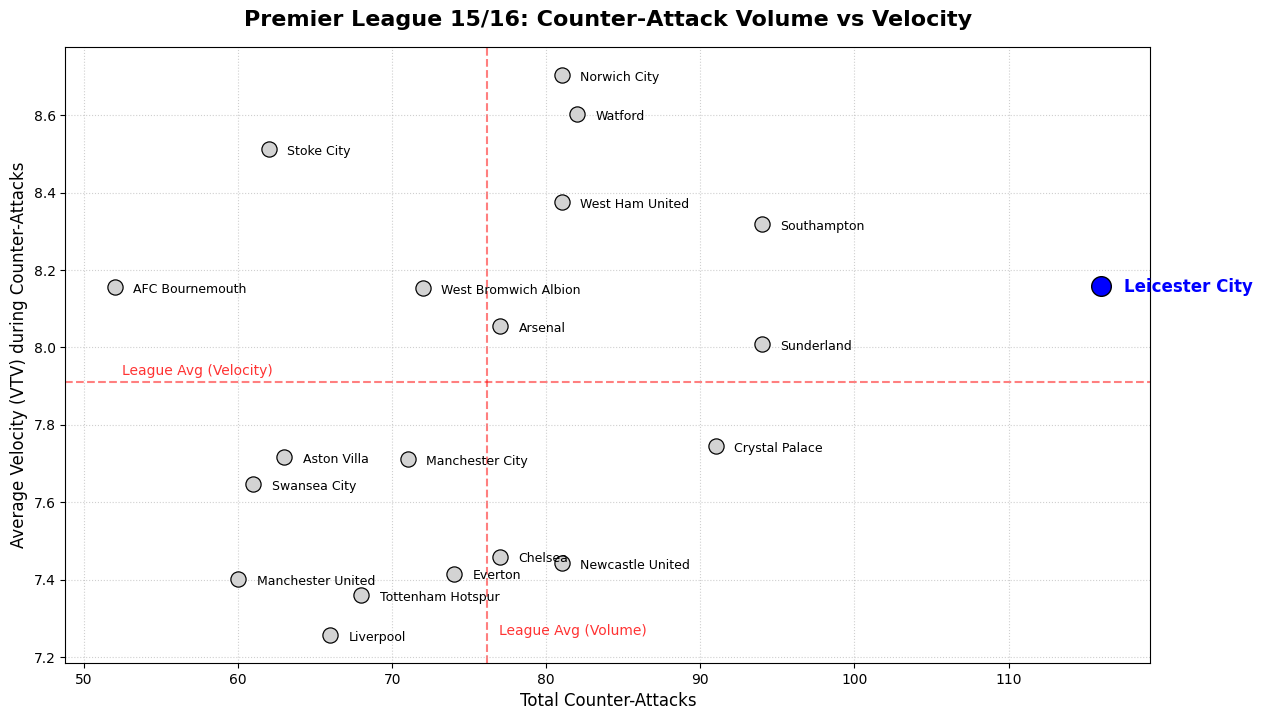

Clean chart saved as 'leicester_counter_attack_map_clean.png'.


In [21]:
# Load the saved summary dataset
summary_df = pd.read_csv('premier_league_1516_tactical_summary.csv')

# Setup the canvas
plt.figure(figsize=(14, 8))

# Calculate league averages to create quadrants
avg_ca = summary_df['Counter-Attack'].mean()
avg_vtv = summary_df['Avg_VTV_Counter_Attack'].mean()

# 1. Plot all teams in standard color
sns.scatterplot(
    data=summary_df,
    x='Counter-Attack',
    y='Avg_VTV_Counter_Attack',
    s=120,
    color='lightgray',
    edgecolor='black',
    zorder=2
)

# 2. Highlight Leicester City
leicester = summary_df[summary_df['possession_team'] == 'Leicester City']
plt.scatter(
    leicester['Counter-Attack'],
    leicester['Avg_VTV_Counter_Attack'],
    s=200,
    color='blue',
    edgecolor='black',
    zorder=3
)

# 3. Add quadrant lines (League Averages)
plt.axvline(avg_ca, color='red', linestyle='--', alpha=0.5, zorder=1)
plt.axhline(avg_vtv, color='red', linestyle='--', alpha=0.5, zorder=1)

# Get dynamic minimum values to place the average labels neatly inside the frame
y_min = summary_df['Avg_VTV_Counter_Attack'].min()
x_min = summary_df['Counter-Attack'].min()

plt.text(avg_ca + 0.8, y_min, 'League Avg (Volume)', color='red', alpha=0.8, fontsize=10)
plt.text(x_min + 0.5, avg_vtv + 0.02, 'League Avg (Velocity)', color='red', alpha=0.8, fontsize=10)

# 4. Label all teams neatly
for i in range(summary_df.shape[0]):
    team_name = summary_df['possession_team'].iloc[i]
    x = summary_df['Counter-Attack'].iloc[i]
    y = summary_df['Avg_VTV_Counter_Attack'].iloc[i]

    # Custom styling for Leicester
    if team_name == 'Leicester City':
        plt.text(x + 1.5, y - 0.015, team_name, fontsize=12, fontweight='bold', color='blue')
    # Standard styling for the rest with adjusted offsets
    else:
        plt.text(x + 1.2, y - 0.015, team_name, fontsize=9)

# 5. Styling and formatting
plt.title('Premier League 15/16: Counter-Attack Volume vs Velocity', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Total Counter-Attacks', fontsize=12)
plt.ylabel('Average Velocity (VTV) during Counter-Attacks', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# 6. Save high-res image
output_image = 'leicester_counter_attack_map_clean.png'
plt.savefig(output_image, dpi=300, bbox_inches='tight')
plt.show()

print(f"Clean chart saved as '{output_image}'.")

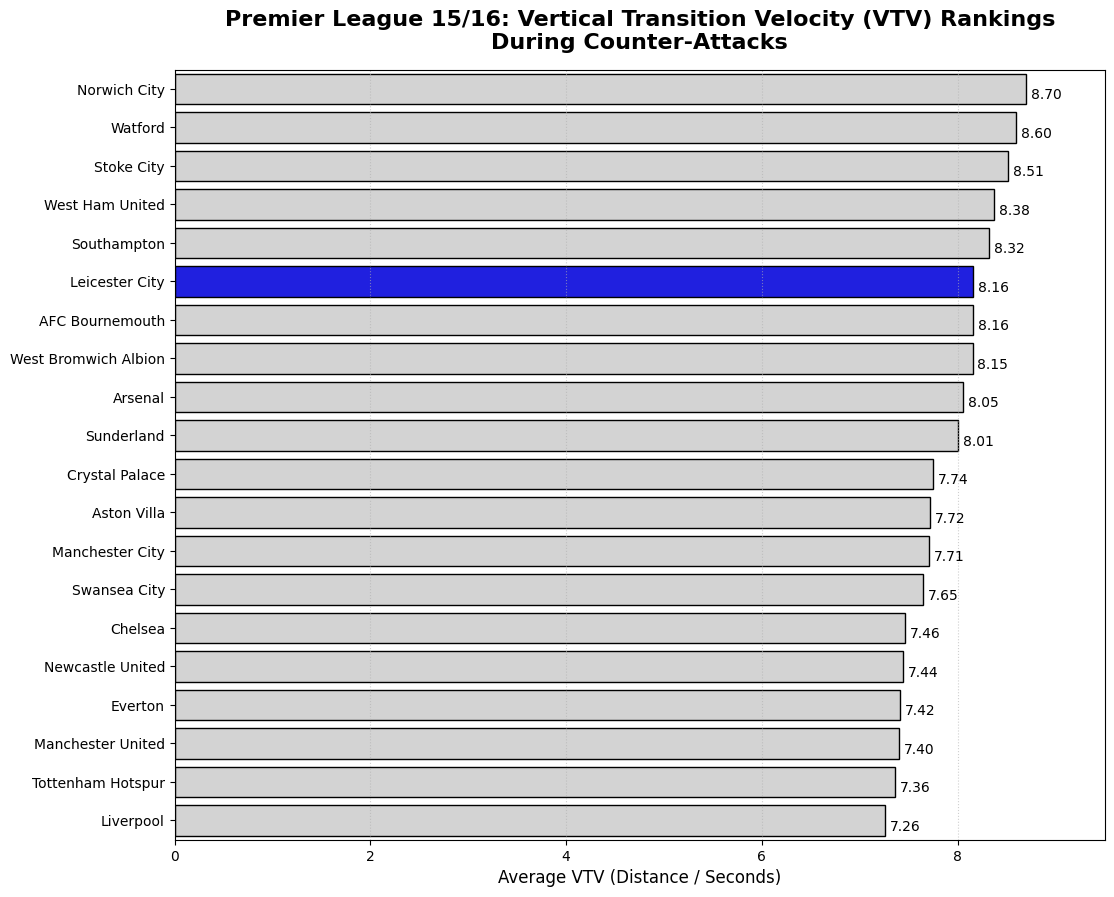

In [22]:
import pandas as pd

# Load the saved summary dataset
summary_df = pd.read_csv('premier_league_1516_tactical_summary.csv')

# Sort data by Average VTV during Counter-Attacks (highest to lowest)
vtv_sorted = summary_df.sort_values(by='Avg_VTV_Counter_Attack', ascending=False).reset_index(drop=True)

# Setup the canvas
plt.figure(figsize=(12, 10))

# Create custom color palette: Blue for Leicester, light gray for the rest
colors = ['blue' if team == 'Leicester City' else 'lightgray' for team in vtv_sorted['possession_team']]

# Plot horizontal bar chart
ax = sns.barplot(
    data=vtv_sorted,
    x='Avg_VTV_Counter_Attack',
    y='possession_team',
    hue='possession_team',
    palette=colors,
    edgecolor='black',
    legend=False
)

# Add the exact VTV score at the end of each bar for precision
for i, v in enumerate(vtv_sorted['Avg_VTV_Counter_Attack']):
    ax.text(v + 0.05, i + 0.15, f'{v:.2f}', fontsize=10, va='center')

# Styling and formatting
plt.title('Premier League 15/16: Vertical Transition Velocity (VTV) Rankings\nDuring Counter-Attacks', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Average VTV (Distance / Seconds)', fontsize=12)
plt.ylabel('', fontsize=12) # Hide the y-axis label since team names are self-explanatory
plt.xlim(0, vtv_sorted['Avg_VTV_Counter_Attack'].max() + 0.8) # Give extra space for the text
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Save high-res image
output_vtv_chart = 'vtv_rankings_bar_chart.png'
plt.savefig(output_vtv_chart, dpi=300, bbox_inches='tight')
plt.show()